In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [54]:
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
df.shape

(20, 11)

In [55]:
df.head(11)

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [56]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [57]:
df.columns

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')

In [58]:
df.index

RangeIndex(start=0, stop=20, step=1)

In [59]:
cols = df.columns[1:]

perihelion = df.iloc[8, 1:].astype(float)
aphelion   = df.iloc[9, 1:].astype(float)
orbital_period_days = df.iloc[10, 1:].astype(float)
orbital_period = orbital_period_days / 365.25

In [60]:
# Perihelion is the closest point in an object’s orbit from the Sun.
# Aphelion is the farthest point in an object’s orbit from the Sun.
# Semi-major axis is half of the longest diameter of an elliptical orbit.

In [61]:
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64

In [62]:
sma_row = pd.Series(
    ["Semi-major axis (10^6 km)"] + list(semi_major_axis.values),
    index=df.columns
)

df = pd.concat([df, sma_row.to_frame().T], ignore_index=True)
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [63]:
df.shape

(21, 11)

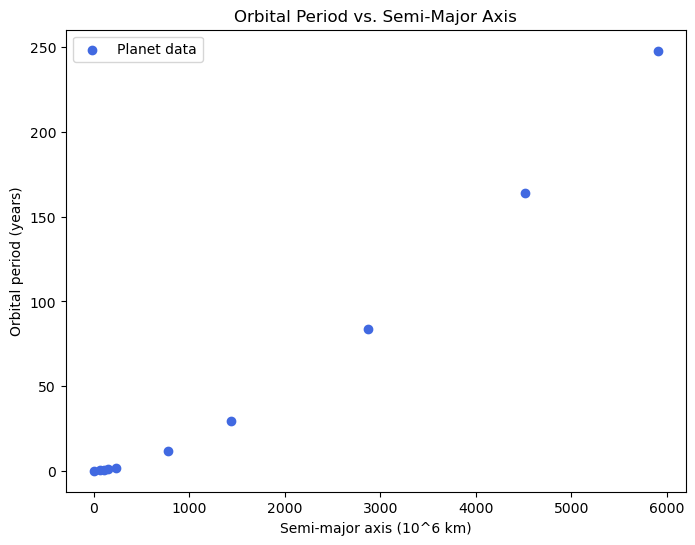

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(semi_major_axis, orbital_period, color="royalblue", label="Planet data")

plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (years)")
plt.title("Orbital Period vs. Semi-Major Axis")
plt.legend()
plt.show()

In [65]:
def keplers_third_law(a, m):
    return m * a**1.5

p0 = [1]
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)
m_fit = popt[0]
print(f"Fit: T = {m_fit:.2f} * a^(3/2)")


Fit: T = 0.00 * a^(3/2)


In [66]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - 1   # one parameter
chi2_reduced = chi2 / dof
chi2_reduced

np.float64(0.3094030451938864)

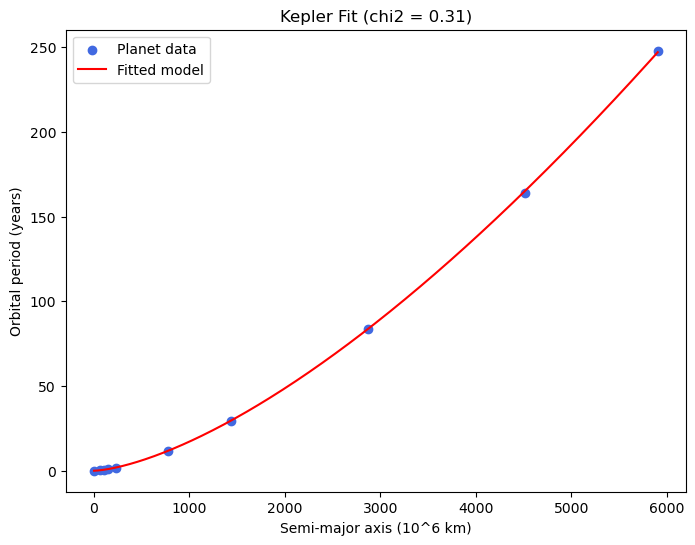

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(semi_major_axis, orbital_period, color="royalblue", label="Planet data")

a_fit = np.linspace(min(semi_major_axis), max(semi_major_axis), 300)
plt.plot(a_fit, keplers_third_law(a_fit, m_fit), color="red", label="Fitted model")

plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (years)")
plt.title(f"Kepler Fit (chi2 = {chi2_reduced:.2f})")
plt.legend()
plt.show()


In [68]:
df.to_csv("kepler.csv", index=False)